<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt



In [8]:
import pandas as pd
import matplotlib.pyplot as plt

NETID = "ttb615"
df = pd.read_csv(f"{NETID}_project_summary.csv", sep=";", header=None,
                 names=["project","commit","author","time","message"])
df["Month"] = pd.to_datetime(df["time"], unit="s").dt.strftime("%Y-%m")
print(len(df))
df.head()

44191


,project,commit,author,time,message,Month
0,ohdsi_webapi,00039d9b4d4f15e202b8c4f9add59b1e73cc2128,SSStanleyZ <szea@spinsys.com>,1716211692,MDACA Spring Boot 3 migration\n,2024-05
1,ohdsi_webapi,000cc5c67e9661bb26b6e487540f11c927453338,Chris Knoll <cknoll@ohdsi.org>,1544718025,Merge 214e50171f39e8d6bef573b866724de0c1263fbe...,2018-12
2,ohdsi_webapi,001752ea5e0670ae4069979fe0aa61bce5d9a115,Peter Moorthamer <peter@moorthamer.be>,1536220139,User Story 1.3.9.5 - Automated integration tes...,2018-09
3,ohdsi_webapi,0020222683e51fca231694002ddc8c1ffdea7b02,Vitaly Koulakov <vitaly.koulakov@gmail.com>,1543433420,Added endpoints for Cohort Characterization ->...,2018-11
4,ohdsi_webapi,002392443dccfdd56bb0d0b22c4a6e81ad8c0b9b,Chris Knoll <cknoll@ohdsi.org>,1512764831,Updated external library refs\ncirce-be -> 1.3...,2017-12


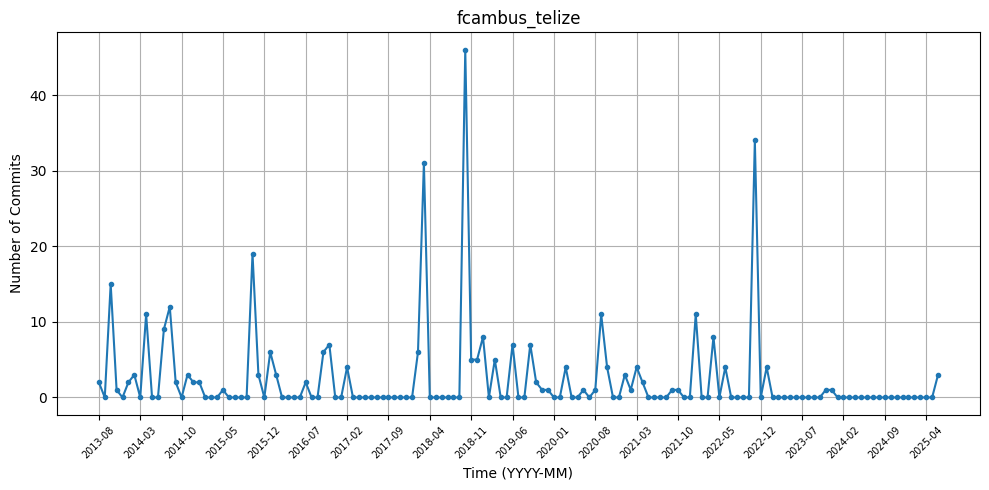

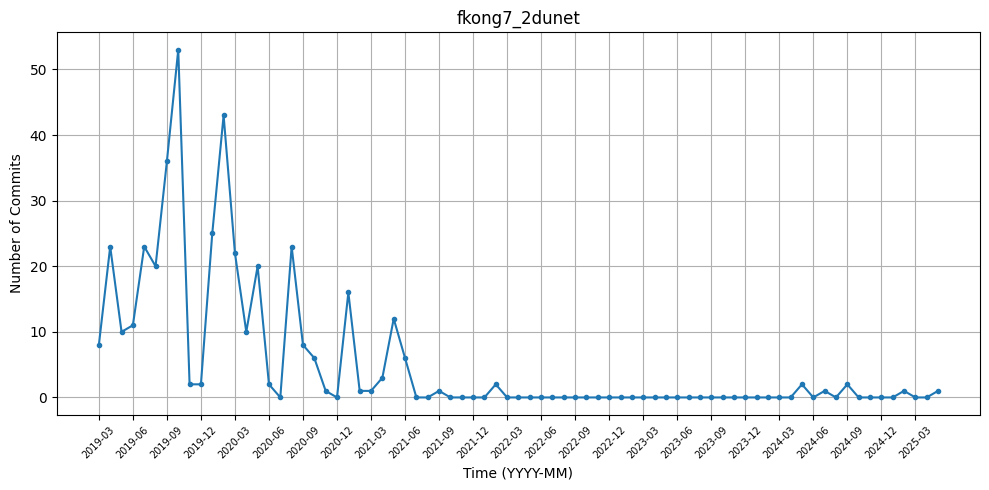

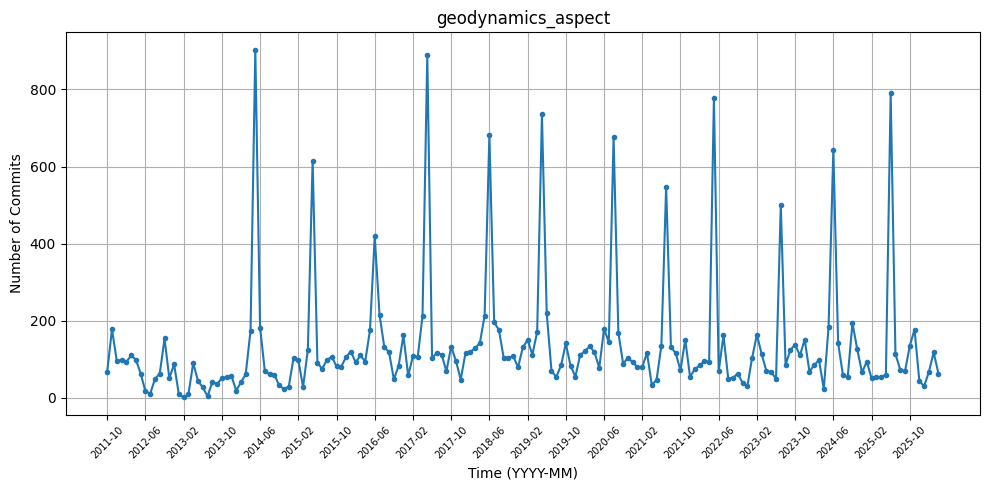

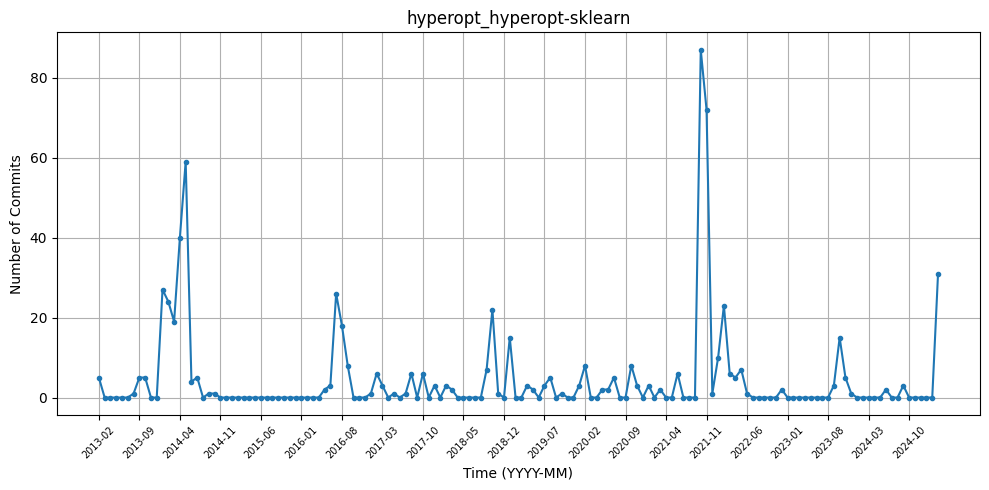

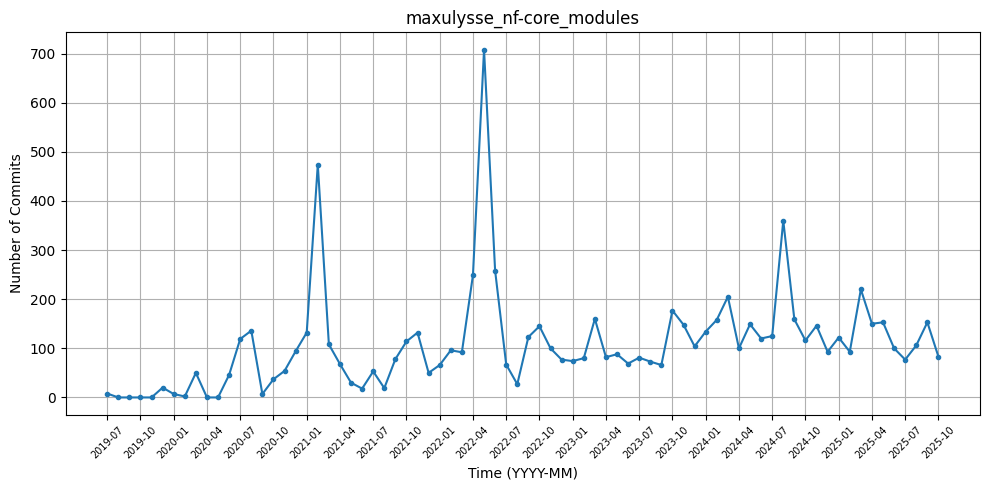

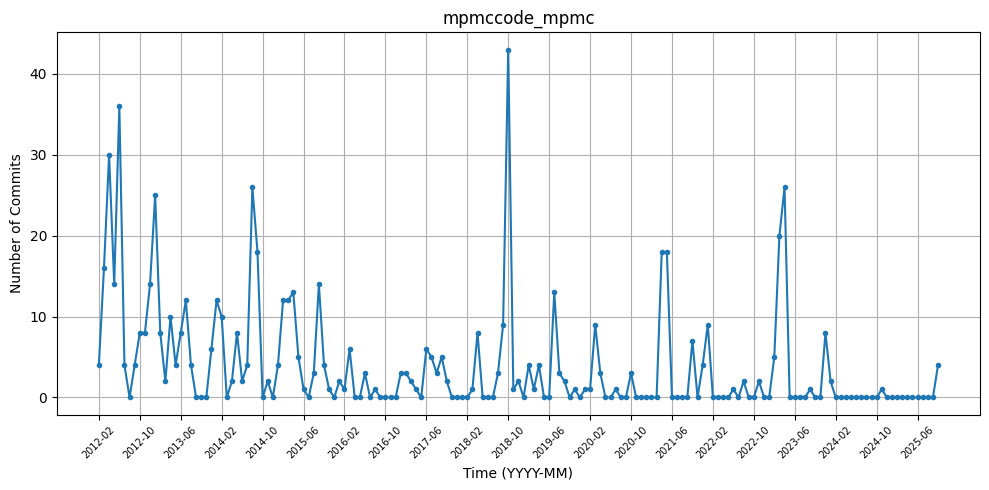

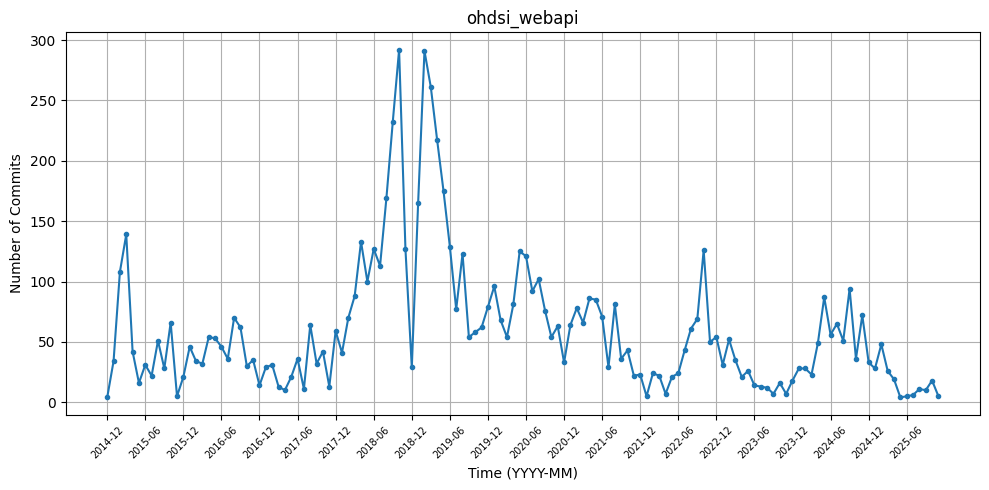

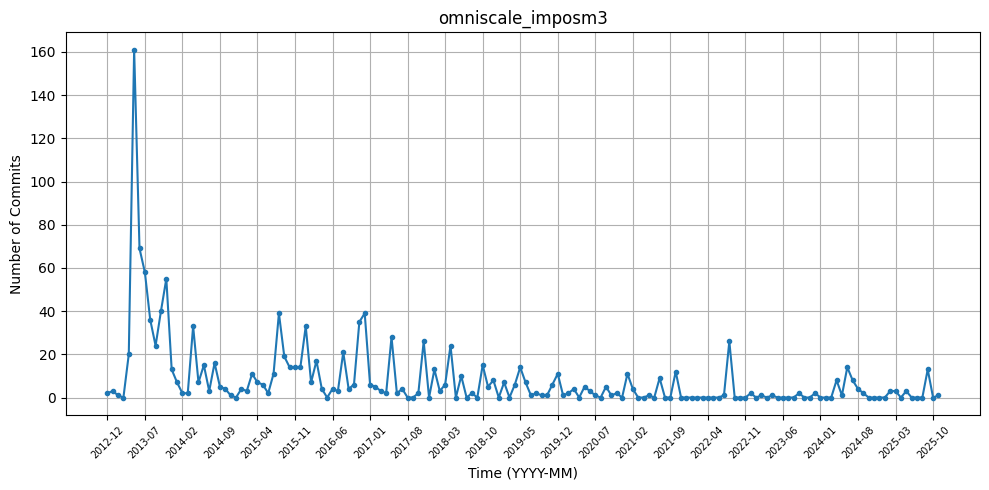

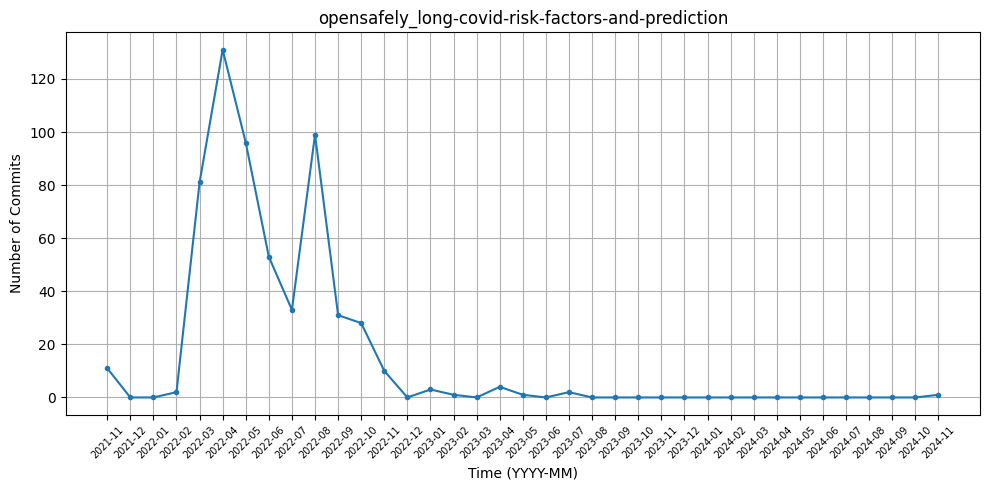

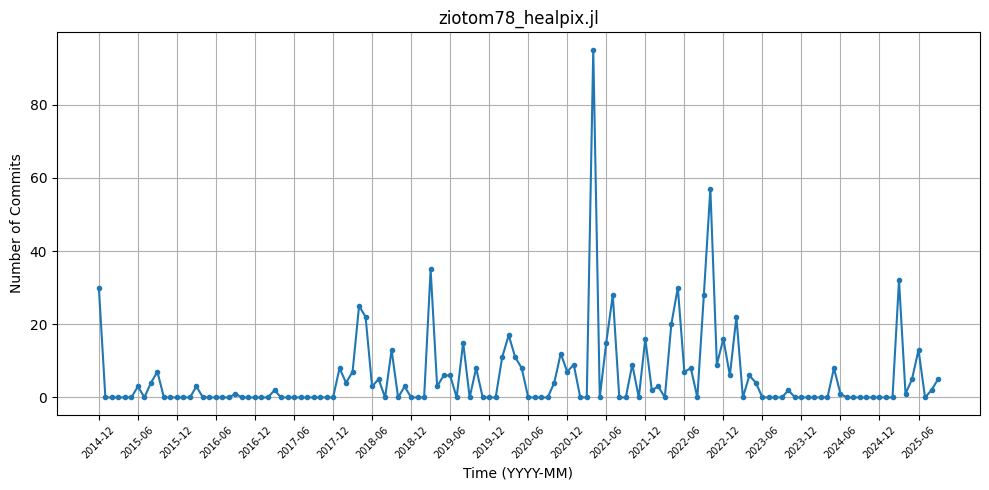

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,fcambus_telize,2024-01,2025-05,17,3,9
1,fkong7_2dunet,2022-03,2024-04,26,7,3
2,geodynamics_aspect,N/A,N/A,0,23494,0
3,hyperopt_hyperopt-sklearn,2014-11,2016-04,18,464,9
4,maxulysse_nf-core_modules,2019-08,2019-11,4,8180,1
5,mpmccode_mpmc,2024-12,2025-09,10,4,10
6,ohdsi_webapi,N/A,N/A,0,7861,0
7,omniscale_imposm3,2021-11,2022-06,8,95,6
8,opensafely_long-covid-risk-factors-and-prediction,2023-08,2024-10,15,1,1
9,ziotom78_healpix.jl,2017-04,2017-12,9,692,11


In [9]:
stats = []
for prj in sorted(df["project"].unique()):
    counts = df[df["project"]==prj].groupby("Month").size()
    all_months = pd.period_range(counts.index.min(), counts.index.max(), freq="M").strftime("%Y-%m")
    ts = counts.reindex(all_months, fill_value=0)
    out = pd.DataFrame({"Month": ts.index, "#Commits": ts.values})
    out.to_csv(f"{NETID}_commits_timeseries_{prj}.csv", sep=";", index=False)

    # plot
    plt.figure(figsize=(10,5))
    plt.plot(out["Month"], out["#Commits"], marker="o", markersize=3, linestyle="-")
    step = max(1, len(out)//20)
    plt.xticks(range(0, len(out), step), out["Month"][::step], rotation=45, fontsize=7)
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{NETID}_timeseries_{prj}.png", dpi=300)
    plt.show()
    plt.close()

    # gaps
    runs, start = [], None
    for i, v in enumerate(ts.values):
        if v == 0 and start is None:
            start = i
        if v != 0 and start is not None:
            runs.append((start, i-1)); start = None
    if runs:
        s, e = max(runs, key=lambda r: r[1]-r[0])
        gs, ge, gl = ts.index[s], ts.index[e], e-s+1
        after = int(ts.iloc[e+1:].sum())
    else:
        gs, ge, gl, after = "N/A", "N/A", 0, int(ts.sum())
    ngaps = sum(1 for s, e in runs if e-s+1 >= 3)
    stats.append({"Project": prj, "LongestGapStart": gs, "LongestGapEnd": ge,
                  "LongestGapLength": gl, "NumCommitsAfterLastGap": after,
                  "NumberOfGapsInTimeline": ngaps})

gaps = pd.DataFrame(stats)
gaps

In [10]:
pattern = {
    "fcambus_telize": "declining",
    "fkong7_2dunet": "declining",
    "geodynamics_aspect": "cyclical",
    "hyperopt_hyperopt-sklearn": "irregular",
    "maxulysse_nf-core_modules": "rising",
    "mpmccode_mpmc": "irregular",
    "ohdsi_webapi": "declining",
    "omniscale_imposm3": "declining",
    "opensafely_long-covid-risk-factors-and-prediction": "declining",
    "ziotom78_healpix.jl": "irregular",
}
gaps["ActivityPattern"] = gaps["Project"].map(pattern)

path = f"{NETID}_project_stats.csv"
with open(path) as f:
    sep = ";" if ";" in f.readline() else ","
old = pd.read_csv(path, sep=sep)
old = old.rename(columns={old.columns[0]: "Project"})
part2 = ["LongestGapStart","LongestGapEnd","LongestGapLength",
         "NumCommitsAfterLastGap","ActivityPattern","NumberOfGapsInTimeline"]
old = old.drop(columns=[c for c in part2 if c in old.columns])
final = old.merge(gaps[["Project"]+part2], on="Project", how="left")
final.to_csv(path, sep=sep, index=False)
final

,Project,#commits,#authors,From,To,#stars,#forks,LastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,ActivityPattern,NumberOfGapsInTimeline
0,fcambus_telize,338,13,1377084651,1750791632,873,138,2026/07/09,2024-01,2025-05,17,3,declining,9
1,fkong7_2dunet,397,9,1553211731,1748543205,15,1,2025/02/28,2022-03,2024-04,26,7,declining,3
2,geodynamics_aspect,23494,347,1318199520,1776492642,311,277,2026/09/28,N/A,N/A,0,23494,cyclical,0
3,hyperopt_hyperopt-sklearn,660,53,1361290194,1742634354,1647,273,2025/03/22,2014-11,2016-04,18,464,irregular,9
4,maxulysse_nf-core_modules,8188,619,1564131265,1761924543,1,0,2026/09/11,2019-08,2019-11,4,8180,rising,1
5,mpmccode_mpmc,654,43,1330027139,1761071129,53,13,2025/10/21,2024-12,2025-09,10,4,irregular,10
6,ohdsi_webapi,7861,211,1417636192,1762475208,152,184,2026/09/28,N/A,N/A,0,7861,declining,0
7,omniscale_imposm3,1270,71,1356527250,1762291878,774,161,2026/08/05,2021-11,2022-06,8,95,declining,6
8,opensafely_long-covid-risk-factors-and-prediction,587,6,1636586992,1732624252,1,0,2024/11/26,2023-08,2024-10,15,1,declining,1
9,ziotom78_healpix.jl,742,29,1419267990,1758788511,58,20,2026/06/24,2017-04,2017-12,9,692,irregular,11


# Interpretation

- **fcambus_telize** (declining, 9 gaps ≥3 months): Bursts of activity in 2013-2018, then sparse commits. Longest gap is 2024-01 to 2025-05.
- **fkong7_2dunet** (declining, 3 gaps): Intense activity in 2019-2020 (likely a research project), then near silence. Longest gap is 2022-03 to 2024-04.
- **geodynamics_aspect** (cyclical, 0 gaps): Continuously active, with large commit spikes about once a year (likely release cycles).
- **hyperopt_hyperopt-sklearn** (irregular, 9 gaps): Unpredictable bursts with long quiet stretches. Longest gap is 2014-11 to 2016-04.
- **maxulysse_nf-core_modules** (rising, 1 gap): One short gap right at the start (2019-08 to 2019-11), then steady growth to hundreds of commits per month.
- **mpmccode_mpmc** (irregular, 10 gaps): Sporadic spikes with many short gaps. Longest gap is 2024-12 to 2025-09.
- **ohdsi_webapi** (declining, 0 gaps): Never inactive, but activity peaked around 2018-2019 and has tapered off.
- **omniscale_imposm3** (declining, 6 gaps): Big early burst, then low steady activity with occasional gaps. Longest gap is 2021-11 to 2022-06.
- **opensafely_long-covid-risk-factors-and-prediction** (declining, 1 gap): One peak in 2022, then almost nothing. Longest gap is 2023-08 to 2024-10.
- **ziotom78_healpix.jl** (irregular, 11 gaps): Irregular bursts, with quiet periods in the early years. Longest gap is 2017-04 to 2017-12.

In [11]:
!zip ttb615_part2.zip ttb615_timeseries_*.png ttb615_commits_timeseries_*.csv ttb615_project_stats.csv
from google.colab import files
files.download("ttb615_part2.zip")

  adding: ttb615_timeseries_fcambus_telize.png (deflated 13%)
  adding: ttb615_timeseries_fkong7_2dunet.png (deflated 17%)
  adding: ttb615_timeseries_geodynamics_aspect.png (deflated 9%)
  adding: ttb615_timeseries_hyperopt_hyperopt-sklearn.png (deflated 14%)
  adding: ttb615_timeseries_maxulysse_nf-core_modules.png (deflated 14%)
  adding: ttb615_timeseries_mpmccode_mpmc.png (deflated 11%)
  adding: ttb615_timeseries_ohdsi_webapi.png (deflated 12%)
  adding: ttb615_timeseries_omniscale_imposm3.png (deflated 15%)
  adding: ttb615_timeseries_opensafely_long-covid-risk-factors-and-prediction.png (deflated 18%)
  adding: ttb615_timeseries_ziotom78_healpix.jl.png (deflated 13%)
  adding: ttb615_commits_timeseries_fcambus_telize.csv (deflated 74%)
  adding: ttb615_commits_timeseries_fkong7_2dunet.csv (deflated 71%)
  adding: ttb615_commits_timeseries_geodynamics_aspect.csv (deflated 67%)
  adding: ttb615_commits_timeseries_hyperopt_hyperopt-sklearn.csv (deflated 73%)
  adding: ttb615_commi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>